In [90]:
#download the correlation results for the RNA-ATAC correlation analysis across all windows
import pandas as pd
cor_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_correlation_ct_results.csv")
cor_res_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj
0,10kb,rpl24,1-2372-3057,0.266306,0.101272,0.994511,0.224565,0.648658
1,10kb,rpl24,1-3427-4032,0.011685,0.943715,0.025159,0.969924,0.013262
2,10kb,rpl24,1-4469-7268,-0.125739,0.445625,0.351031,0.622558,0.205820
3,10kb,rpl24,1-9541-9969,-0.171639,0.296122,0.528530,0.476371,0.322055
4,10kb,rpl24,1-11007-12962,-0.113314,0.492185,0.307872,0.663006,0.178483


# Different here:
"Dedublication" of gene-peak pairs, meaning we keep only the first occurrence of each pair across all windows
- ordering by window size, we keep the pair with the smallest window size

In [91]:

# classify every peak–gene pair into one of three categories 
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# Make window categorical and ordered
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
cor_res_df = cor_res_df.sort_values("window", ascending=True)
cor_res_df

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# "Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    cor_res_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

# Sort by window 
pair_summary = pair_summary.sort_values("window", ascending=True)
pair_summary

# Sanity check - how many times each gene-peak pair appears in the summary
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
pair_counts['count'].value_counts()

# Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = pair_summary.groupby(['window', 'gene', 'category']).size().reset_index(name="count")
summary_counts


/tmp/ipykernel_863637/3599608733.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = pair_summary.groupby(['window', 'gene', 'category']).size().reset_index(name="count")


,window,gene,category,count
0,10kb,a1cf,non-significant,7
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,4
3,10kb,a2ml,non-significant,9
4,10kb,a2ml,sig. negative,0
...,...,...,...,...
229987,100kb,zzef1,sig. negative,0
229988,100kb,zzef1,sig. positive,12
229989,100kb,zzz3,non-significant,45
229990,100kb,zzz3,sig. negative,0


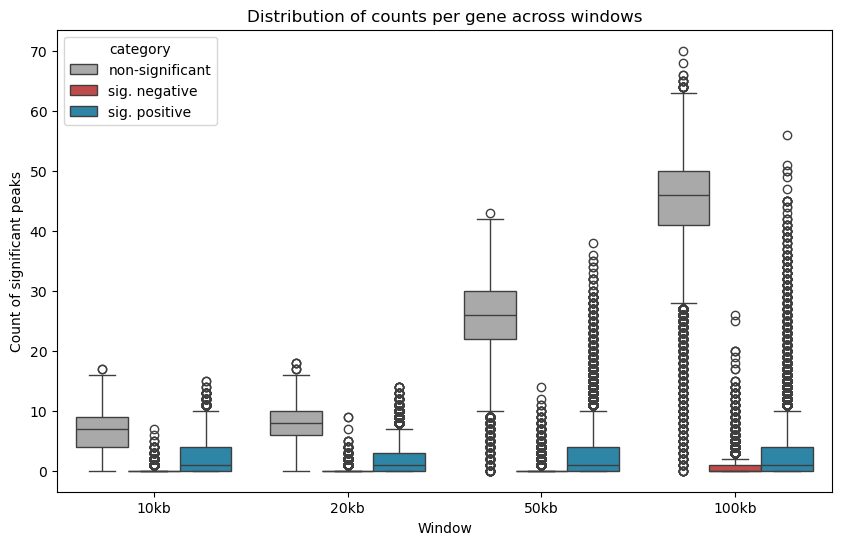

In [92]:
# Make boxplot for each window showing the distribution of counts per gene

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
   "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
    "non-significant": "#A9A9A9"
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=summary_counts, x="window", y="count", hue="category", palette=category_colors)
plt.title("Distribution of counts per gene across windows")
plt.xlabel("Window")
plt.ylabel("Count of significant peaks")
plt.show()

/tmp/ipykernel_863637/3422499663.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


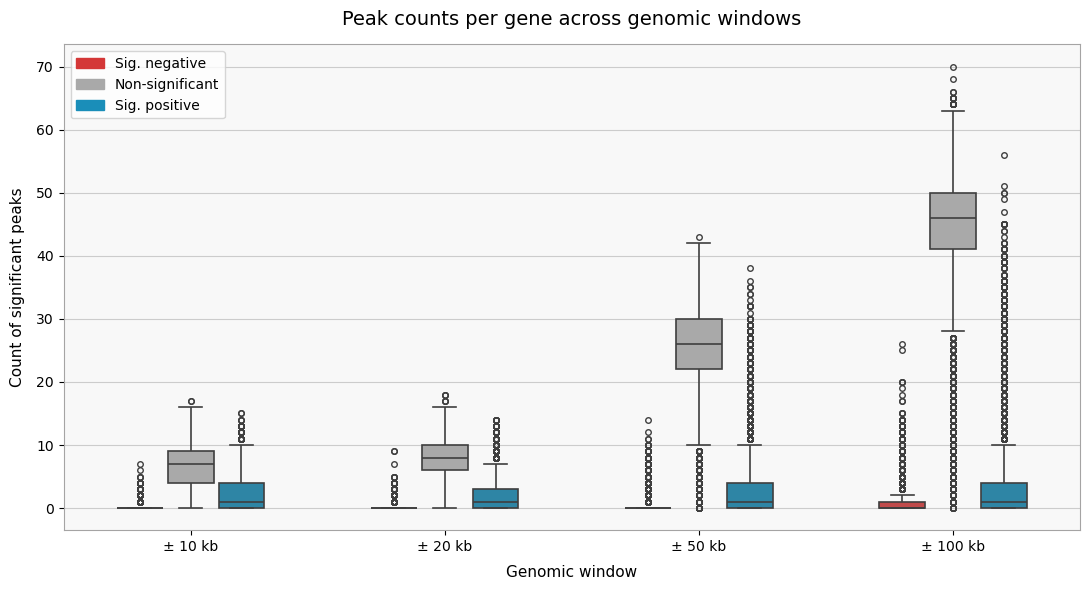

In [107]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "± 10 kb",
    "20kb":  "± 20 kb",
    "50kb":  "± 50 kb",
    "100kb": "± 100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("Count of significant peaks", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(handles=handles, frameon=True, fontsize=10,
          loc="upper left", title_fontsize=10)

plt.tight_layout()
fig.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/first_pair_count_cor_ct.png", dpi=300)
plt.show()

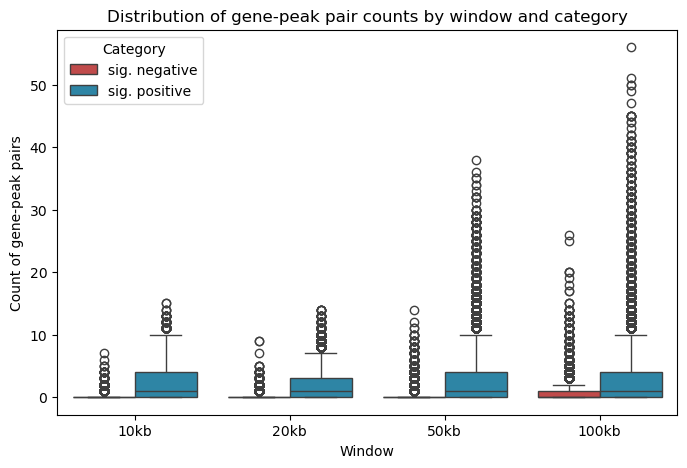

In [96]:
# Plot boxplot for each window color by category
plt.figure(figsize=(8, 5))
only_sig_df = summary_counts[summary_counts['category']!="non-significant"]

category_colors = {
   "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}
sns.boxplot(
    data=data_plot, 
    x="window", y="count", hue="category", palette=category_colors)
plt.title("Distribution of gene-peak pair counts by window and category")
plt.xlabel("Window")
plt.ylabel("Count of gene-peak pairs")
plt.legend(title="Category")
plt.show()

/tmp/ipykernel_863637/872590100.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


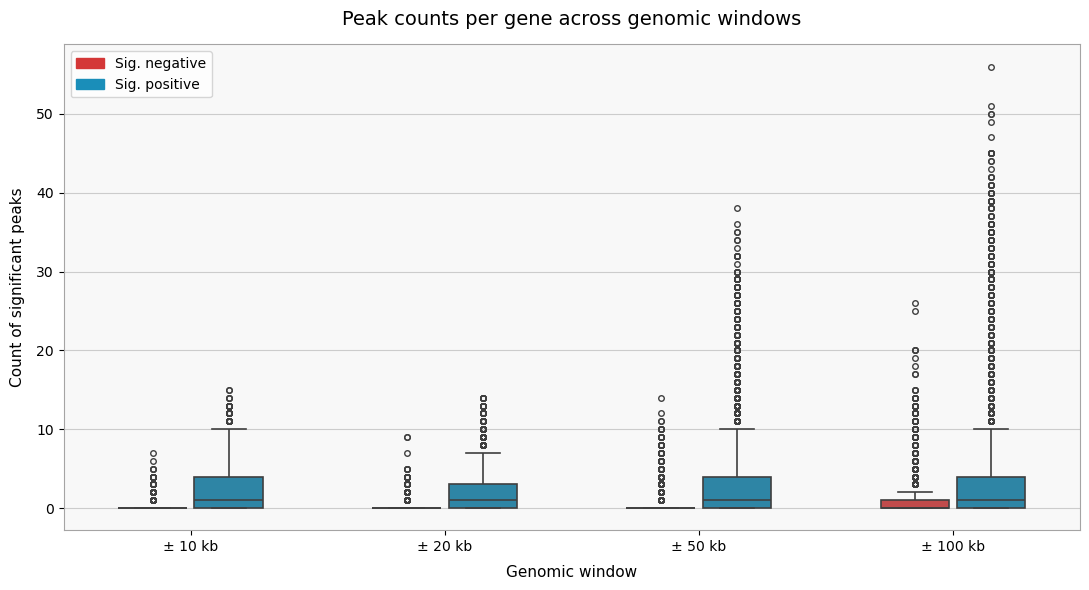

In [108]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "± 10 kb",
    "20kb":  "± 20 kb",
    "50kb":  "± 50 kb",
    "100kb": "± 100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("Count of significant peaks", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(handles=handles, frameon=True, fontsize=10,
          loc="upper left", title_fontsize=10)

plt.tight_layout()
fig.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/first_pair_count_cor_ct2.png", dpi=300)
plt.show()

In [235]:
#plotting every boxplot of each method (cor & ols) in one plot
plot_lm_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/ols_peak_count_summary.csv")

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}
plot_lm_df["window"] = pd.Categorical(
    plot_lm_df["window"],
    categories=window_labels,
    ordered=True,
)

#now read in the correlation results for the RNA-ATAC correlation analysis across all windows
plot_cor_df = agg_plot_df.copy()
plot_cor_df["window"] = pd.Categorical(
    plot_cor_df["window"],
    categories=window_labels,
    ordered=True,
)

#now first add a column for each df to distinguish the method
plot_lm_df["method"] = "OLS"
plot_cor_df["method"] = "Correlation"
#then concatenate the two dfs
plot_cor_lm_df = pd.concat([plot_lm_df, plot_cor_df], ignore_index=True)
plot_cor_lm_df["window"] = pd.Categorical(
    plot_cor_lm_df["window"],
    categories=window_labels,
    ordered=True,
)

#Remove the 'count_ols' column 

plot_cor_lm_df = plot_cor_lm_df.drop(columns=["count_ols"])
plot_cor_lm_df.head()


,window,gene,category,count,method
0,100kb,aadacl4,sig. positive,1,OLS
1,100kb,abcb7,sig. negative,10,OLS
2,100kb,abcb7,sig. positive,12,OLS
3,100kb,abcc13,sig. negative,3,OLS
4,100kb,abcc13,sig. positive,1,OLS


In [236]:
plot_lm = plot_lm_df[['window','category','gene','count']].assign(method='OLS')
plot_cor = plot_cor_df[['window','category','gene','count']].assign(method='Correlation')
plot_both = pd.concat([plot_lm, plot_cor], ignore_index=True)

plot_both = plot_cor_lm_df.melt(
    id_vars=['window','category','gene'],
    value_vars=['count_lm','count_cor'],
    var_name='method', value_name='count'
)
plot_both['method'] = plot_both['method'].map({'count_lm':'OLS','count_cor':'Correlation'})

method_palette = {'OLS': '#1A8EB9', 'Correlation': '#D43737'}

plt.figure(figsize=(10,6))
sns.boxplot(
    data=plot_both.dropna(subset=['count']),
    x='window', y='count', hue='method',
    order=window_labels, hue_order=['OLS','Correlation'],
    palette=method_palette, showfliers=True
)
plt.title("Distribution of gene-peak pair counts by window and method")
plt.xlabel("Window")
plt.ylabel("Count of gene-peak pairs")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

ValueError: value_name (count) cannot match an element in the DataFrame columns.

In [220]:
plot_lm_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/ols_peak_count_summary.csv")

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}
plot_lm_df["window"] = pd.Categorical(
    plot_lm_df["window"],
    categories=window_labels,
    ordered=True,
)
plot_lm_df.head()

,window,gene,category,count,count_ols
0,100kb,aadacl4,sig. positive,1,1
1,100kb,abcb7,sig. negative,10,10
2,100kb,abcb7,sig. positive,12,12
3,100kb,abcc13,sig. negative,3,3
4,100kb,abcc13,sig. positive,1,1


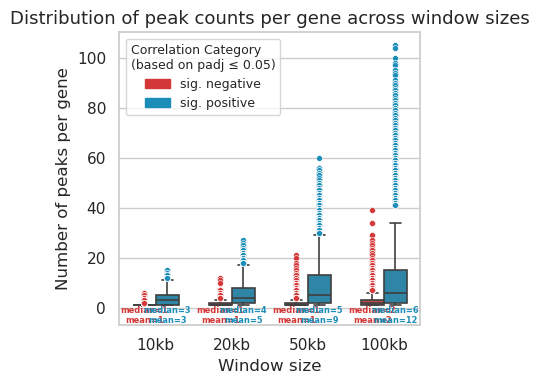

In [181]:
# Plotting the distribution of peak counts per gene across all window sizes (aggregated by category)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

window_labels  = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}

agg_plot_df = agg_cor_df[agg_cor_df["category"] != "non-significant"].copy()
agg_plot_df["window"] = pd.Categorical(
    agg_plot_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=agg_plot_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    showfliers=True,
    flierprops=dict(
        marker=".",
        markersize=2.5,
        alpha=0.5,
        markeredgewidth=0,
    ),
    ax=ax,
)

# ── Y-axis: extend bottom for annotations ─────────────────────────────────────
ymin_current, ymax_current = ax.get_ylim()
y_bottom = -7
ax.set_ylim(y_bottom, ymax_current)

# ── Annotate median & mean below y=0 ──────────────────────────────────────────
n_groups    = len(category_order)
total_width = 0.6
box_width   = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = agg_plot_df[agg_plot_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med  = vals.median()
        y_mean = vals.mean()

        ax.text(
            x=x_pos,
            y=ax.get_ylim()[0] + 0.00001 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            s=f"median={int(y_med):,}\nmean={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── Annotate top 10 outliers per (window, category) ───────────────────────────
# x-positions of each box mirror the boxplot dodge layout exactly
x_positions = {}
for w_idx, window_label in enumerate(window_labels):
    for c_idx, cat in enumerate(category_order):
        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        x_positions[(window_label, cat)] = x_pos

for window_label in window_labels:
    for cat in category_order:
        sel  = (agg_plot_df["window"] == window_label) & (agg_plot_df["category"] == cat)
        vals = agg_plot_df.loc[sel, "count"]
        if vals.empty:
            continue

        # IQR upper fence — same rule the boxplot whisker uses
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        upper_fence = q3 + 1.5 * (q3 - q1)

        # top 10 points strictly above the upper fence
        outlier_rows = (
            agg_plot_df.loc[sel & (agg_plot_df["count"] > upper_fence)]
            .nlargest(1000, "count")
        )

        x_base = x_positions[(window_label, cat)]
        color  = category_colors[cat]

        for _, row in outlier_rows.iterrows():
            gene_label = row.get("gene", row.get("gene_id", ""))   # adapt column name if needed
            y_val      = row["count"]

            # highlight dot
            ax.scatter(x_base, y_val, s=18, color=color, zorder=5,
                       edgecolors="white", linewidths=0.4)

           

# ── Labels + legend ────────────────────────────────────────────────────────────
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--", alpha=0.4, zorder=0)
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Correlation Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_cor_aggregated_2ct.png",
    dpi=300, bbox_inches="tight",
)
plt.show()

window      100kb    10kb    20kb    50kb
threshold                                
0.001      0.0335  0.1174  0.0861  0.0534
0.010      0.0647  0.1896  0.1463  0.0973
0.050      0.1157  0.2818  0.2286  0.1626
0.100      0.1585  0.3425  0.2859  0.2128
0.200      0.2307  0.4315  0.3732  0.2932


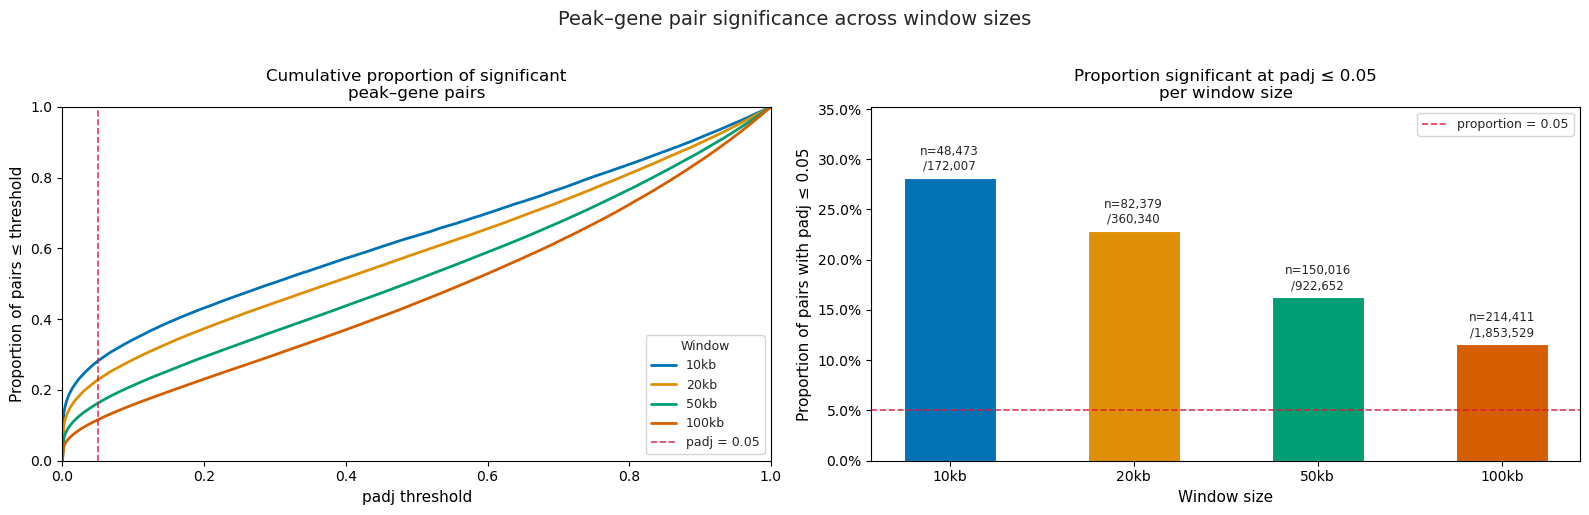

In [3]:
#Plotting the proportion of significant correlations (padj < 0.05) for each window size
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Continuous proportion curve across thresholds 
thresholds   = np.linspace(0, 1, 500)          # padj thresholds from 0 to 1
window_labels = ["10kb", "20kb", "50kb", "100kb"]

# build a tidy table: one row per (window, threshold)
prop_records = []
for window_label in window_labels:
    subset = cor_res_df[cor_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    if n_total == 0:
        continue
    for t in thresholds:
        prop = (subset <= t).sum() / n_total
        prop_records.append({
            "window":    window_label,
            "threshold": t,
            "proportion": prop,
            "n_total":   n_total,
        })

prop_df = pd.DataFrame(prop_records)

# 2. Summary table at biologically meaningful cutoffs 
cutoffs = [0.001, 0.01, 0.05, 0.1, 0.2]
summary_records = []
for window_label in window_labels:
    subset = cor_res_df[cor_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    for t in cutoffs:
        n_sig  = (subset <= t).sum()
        prop   = n_sig / n_total if n_total > 0 else np.nan
        summary_records.append({
            "window":     window_label,
            "threshold":  t,
            "n_total":    n_total,
            "n_sig":      n_sig,
            "proportion": prop,
        })

summary_df = pd.DataFrame(summary_records)
print(summary_df.pivot(index="threshold", columns="window", values="proportion")
                .round(4)
                .to_string())

# 3. Plot 
palette = sns.color_palette("colorblind", n_colors=len(window_labels))
color_map = dict(zip(window_labels, palette))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

# --- left panel: full proportion curve ---------------------------------------
ax = axes[0]
for window_label in window_labels:
    wdf = prop_df[prop_df["window"] == window_label]
    ax.plot(
        wdf["threshold"], wdf["proportion"],
        label=window_label,
        color=color_map[window_label],
        linewidth=2.0
    )

ax.axvline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="padj = 0.05")
ax.set_xlabel("padj threshold", fontsize=11)
ax.set_ylabel("Proportion of pairs ≤ threshold", fontsize=11)
ax.set_title("Cumulative proportion of significant\npeak–gene pairs", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: bar chart at fixed cutoffs ---------------------------------
ax = axes[1]
bar_df = summary_df[summary_df["threshold"] == 0.05].copy()
bars = ax.bar(
    bar_df["window"],
    bar_df["proportion"],
    color=[color_map[w] for w in bar_df["window"]],
    edgecolor="white",
    linewidth=0.8,
    width=0.5
)

# annotate bars with absolute counts
for bar, (_, row) in zip(bars, bar_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={int(row['n_sig']):,}\n/{int(row['n_total']):,}",
        ha="center", va="bottom", fontsize=8.5
    )

ax.axhline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="proportion = 0.05")
ax.set_xlabel("Window size", fontsize=11)
ax.set_ylabel("Proportion of pairs with padj ≤ 0.05", fontsize=11)
ax.set_title("Proportion significant at padj ≤ 0.05\nper window size", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, bar_df["proportion"].max() * 1.25)
ax.legend(fontsize=9)

fig.suptitle("Peak–gene pair significance across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_proportion_significant_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

1. Overlapping KDE Kernel Density Estimate — best for shape comparison

KDE is a smoothed approximation of the underlying probability distribution of your data. Instead of counting observations into discrete bins like a histogram, it places a small smooth "bump" (the kernel, usually a Gaussian) on each data point and sums them all up into one continuous curve.
The most direct way to compare distributional shape across all four windows simultaneously. 
- The peak of the curve shows where most peak–gene correlations concentrate
- The width reflects how spread out correlations are — a wider KDE for 100kb vs 10kb directly visualises signal dilution
- Asymmetry around r = 0 shows whether positive or negative correlations dominate

Key limitation: KDE is an estimate, not the truth. With millions of pairs it is very stable, but the smoothing can obscure sharp features like a spike at r = 0 (many near-zero pairs) or make the tails look heavier than they are.

2. ECDF — Empirical Cumulative Distribution Function

ECDF is the exact, assumption-free version of the CDF you already used for padj — applied now to r values. For each possible value of r on the x-axis, the ECDF answers:
- "What fraction of my peak–gene pairs have a correlation ≤ this value?"

It is constructed by simply sorting all r values and plotting them against their rank divided by n:
- The y-value at r = 0 is the exact fraction of negatively correlated pairs — no estimation, no binning
- The horizontal gap between two window curves at any r tells you directly how the proportion differs between windows at that exact correlation strength
- A curve shifted left means that window has more negative or weaker correlations overall

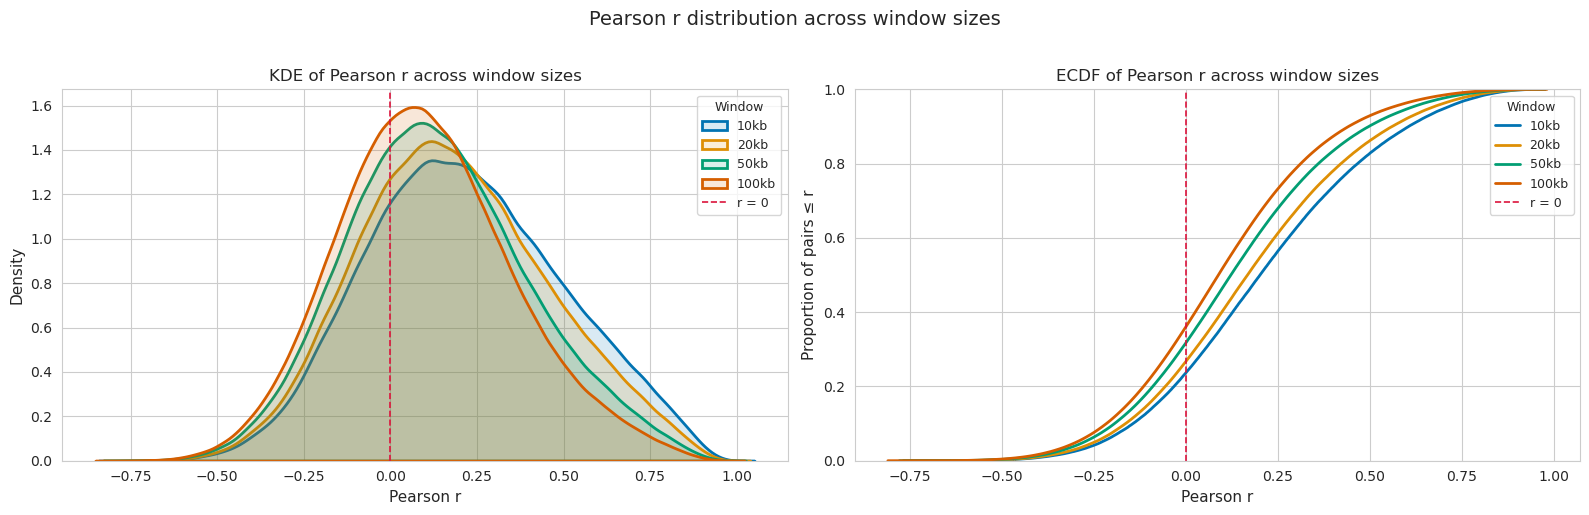

In [4]:
# ── KDE + ECDF combined figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("colorblind", n_colors=4)

# --- left panel: KDE ----------------------------------------------------------
ax_kde = axes[0]
for color, window_label in zip(palette, window_labels):
    subset = cor_res_df[cor_res_df["window"] == window_label]["correlation"].dropna()
    sns.kdeplot(subset, ax=ax_kde, label=window_label, color=color,
                linewidth=2.0, fill=True, alpha=0.15)

ax_kde.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="r = 0")
ax_kde.set_xlabel("Pearson r", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("KDE of Pearson r across window sizes", fontsize=12)
ax_kde.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: ECDF --------------------------------------------------------
ax_ecdf = axes[1]
for color, window_label in zip(palette, window_labels):
    subset = cor_res_df[cor_res_df["window"] == window_label]["correlation"].dropna()
    sns.ecdfplot(subset, ax=ax_ecdf, label=window_label, color=color, linewidth=2.0)

ax_ecdf.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="r = 0")
ax_ecdf.set_xlabel("Pearson r", fontsize=11)
ax_ecdf.set_ylabel("Proportion of pairs ≤ r", fontsize=11)
ax_ecdf.set_title("ECDF of Pearson r across window sizes", fontsize=12)
ax_ecdf.legend(title="Window", fontsize=9, title_fontsize=9)

fig.suptitle("Pearson r distribution across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_pearson_r_kde_ecdf_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

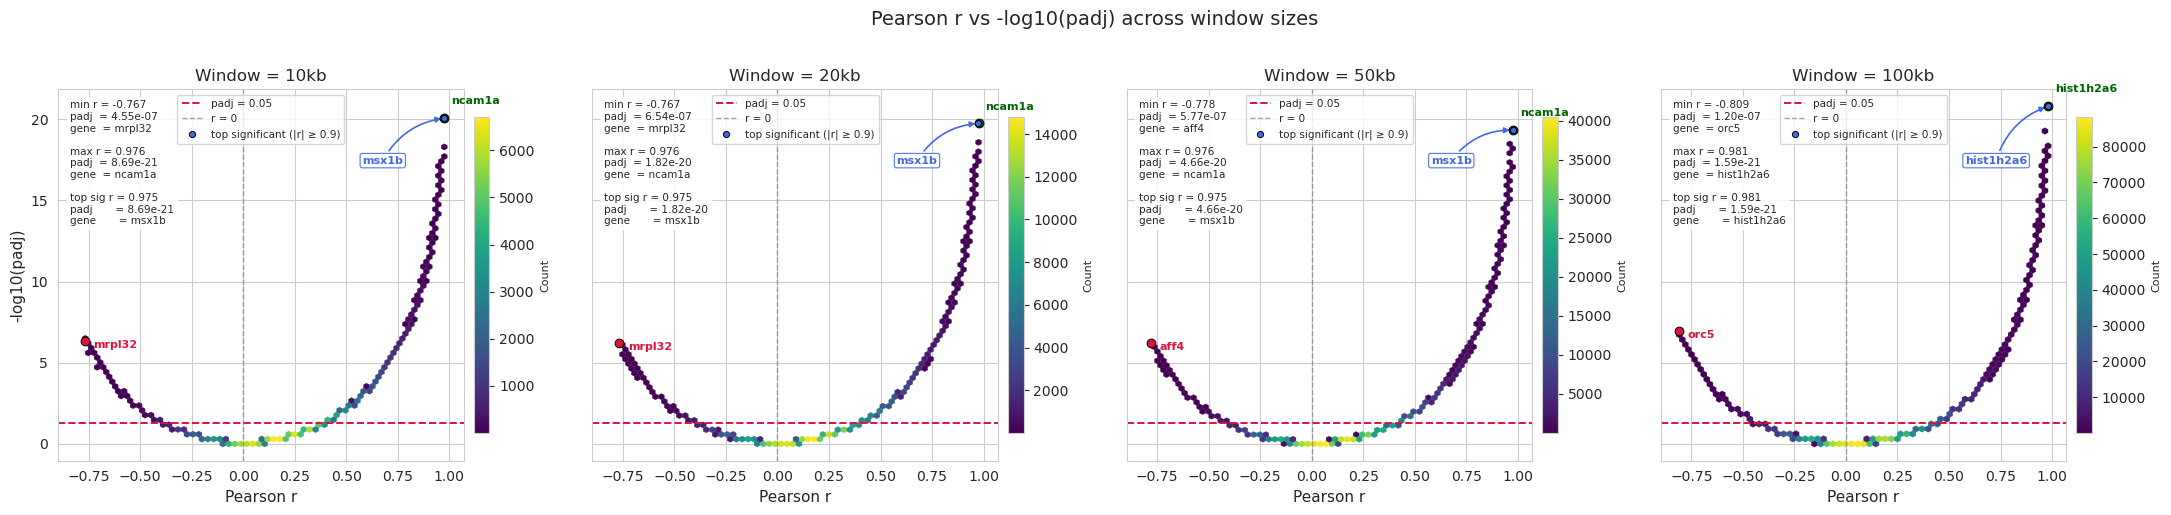

In [73]:
# Scatterplot of Pearson correlation coefficients vs padj for all window sizes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if cor_res_df.empty:
    print("No valid correlation/padj pairs found across windows.")
else:
    window_labels    = ["10kb", "20kb", "50kb", "100kb"]
    threshold_y      = -np.log10(0.05)
    highlight_colors = {
        "min":     "crimson",
        "max":     "darkgreen",
        "top_sig": "royalblue"
    }

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

    for i, (ax, window_label) in enumerate(zip(axes, window_labels)):
        subset = cor_res_df[cor_res_df["window"] == window_label].dropna(
            subset=["correlation", "neglog10_padj"]
        )

        if subset.empty:
            ax.text(0.5, 0.5, "No data",
                    transform=ax.transAxes, ha="center", va="center")
            ax.set_title(f"Window = {window_label}", fontsize=12)
            continue

        # ── hexbin ────────────────────────────────────────────────────────────
        hb = ax.hexbin(
            subset["correlation"],
            subset["neglog10_padj"],
            gridsize=60,
            cmap="viridis",
            mincnt=1,
            linewidths=0.2,
        )
        cb = fig.colorbar(hb, ax=ax, pad=0.02, shrink=0.85)
        cb.set_label("Count", fontsize=8)

        # ── reference lines ───────────────────────────────────────────────────
        ax.axhline(threshold_y, color="crimson", linestyle="--",
                   linewidth=1.4, label="padj = 0.05")
        ax.axvline(0.0, color="grey", linestyle="--",
                   linewidth=1.0, alpha=0.7, label="r = 0")

        # ── min/max correlation ───────────────────────────────────────────────
        min_row = subset.loc[subset["correlation"].idxmin()]
        max_row = subset.loc[subset["correlation"].idxmax()]

        for row, color, xytext in [
            (min_row, highlight_colors["min"], (6, -5)),
            (max_row, highlight_colors["max"], (5, 10)),
        ]:
            ax.scatter(
                row["correlation"], row["neglog10_padj"],
                s=40, color=color, edgecolor="black",
                linewidth=0.7, zorder=5
            )
            ax.annotate(
                row["gene"],
                (row["correlation"], row["neglog10_padj"]),
                textcoords="offset points",
                xytext=xytext,
                fontsize=8, color=color, weight="bold"
            )

        # ── most significant pair with |r| >= 0.9 ────────────────────────────
        strong_sig  = subset[subset["correlation"].abs() >= 0.9]
        top_sig_row = None

        if not strong_sig.empty:
            top_sig_row = strong_sig.loc[strong_sig["neglog10_padj"].idxmax()]

            ax.scatter(
                top_sig_row["correlation"], top_sig_row["neglog10_padj"],
                s=20, color=highlight_colors["top_sig"], edgecolor="black",
                linewidth=0.7, zorder=5, label="top significant (|r| ≥ 0.9)"
            )

            # ── arrow pointing from label to data point ───────────────────────
            # place the label in the lower-right axes corner (axes coordinates)
            # and draw an arrow from there to the actual data point
            ax.annotate(
                top_sig_row["gene"],
                xy=(                                      # arrow tip  → data point
                    top_sig_row["correlation"],
                    top_sig_row["neglog10_padj"]
                ),
                xycoords="data",
                xytext=(0.75, 0.8),                      # label anchor (axes fraction)
                textcoords="axes fraction",
                fontsize=8,
                color=highlight_colors["top_sig"],
                weight="bold",
                arrowprops=dict(
                    arrowstyle="-|>",                     # solid arrow head
                    color=highlight_colors["top_sig"],
                    lw=1.2,
                    connectionstyle="arc3,rad= -0.25",      # gentle curve avoids overlap
                ),
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    edgecolor=highlight_colors["top_sig"],
                    alpha=0.9,
                    linewidth=0.8
                )
            )

        # ── text box with all three annotated pairs ───────────────────────────
        top_sig_text = (
            f"\n\ntop sig r = {top_sig_row['correlation']:.3f}\n"
            f"padj       = {top_sig_row['padj']:.2e}\n"
            f"gene       = {top_sig_row['gene']}"
            if top_sig_row is not None else "\ntop sig: none (|r| < 0.3)"
        )

        annotation = (
            f"min r = {min_row['correlation']:.3f}\n"
            f"padj  = {min_row['padj']:.2e}\n"
            f"gene  = {min_row['gene']}\n\n"
            f"max r = {max_row['correlation']:.3f}\n"
            f"padj  = {max_row['padj']:.2e}\n"
            f"gene  = {max_row['gene']}"
            f"{top_sig_text}"
        )
        ax.text(
            0.03, 0.97, annotation,
            transform=ax.transAxes,
            ha="left", va="top", fontsize=7.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        ax.set_title(f"Window = {window_label}", fontsize=12)
        ax.set_xlabel("Pearson r", fontsize=11)
        ax.set_ylabel("-log10(padj)" if i == 0 else "", fontsize=11)
        ax.legend(loc="upper center", fontsize=7.5, frameon=True)

    fig.suptitle(
        "Pearson r vs -log10(padj) across window sizes",
        y=1.02, fontsize=14
    )
    plt.tight_layout()

    fig.savefig(
        "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
        "peak_gene_r_padj_scatter_sig_ct.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

    


    

In [194]:
#classify every peak–gene pair into one of three categories and count how many pairs fall into each category per window and gene
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

agg_cor_df = (
    cor_res_df
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)

agg_cor_df.head()



,window,gene,category,count
0,100kb,a1cf,non-significant,87
1,100kb,a1cf,sig. positive,8
2,100kb,a2ml,non-significant,73
3,100kb,a2ml,sig. negative,1
4,100kb,a2ml,sig. positive,3


In [180]:
#save the aggregated counts for later use
agg_cor_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/agg_cor_df_ct.csv", index=False)

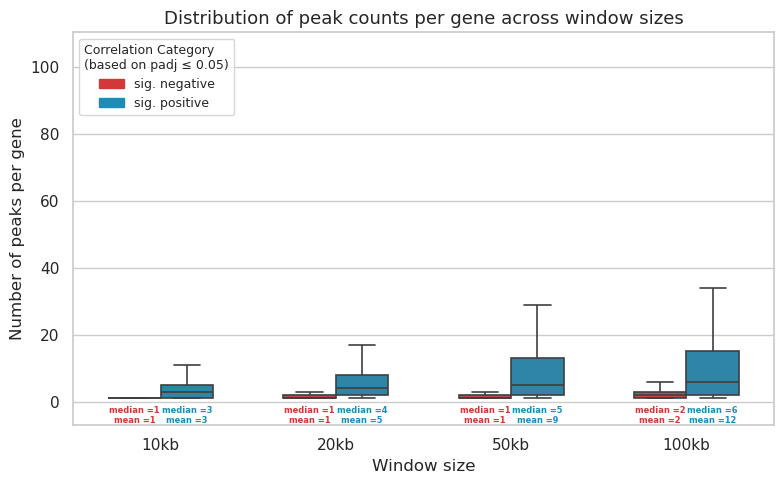

In [138]:
# Plotting the distribution of peak counts per gene across all window sizes (aggregated by category)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

window_labels  = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative": "#D43737",
    "sig. positive": "#1A8EB9",
}

agg_plot_df = agg_cor_df[agg_cor_df["category"] != "non-significant"].copy()
agg_plot_df["window"] = pd.Categorical(
    agg_plot_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=agg_plot_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    showfliers=True,
    flierprops=dict(
        marker=".",
        markersize=2.5,
        alpha=0.5,
        markeredgewidth=0,
    ),
    ax=ax,
)

# ── Y-axis: extend bottom for annotations ─────────────────────────────────────
ymin_current, ymax_current = ax.get_ylim()
y_bottom = -7
ax.set_ylim(y_bottom, ymax_current)

# ── Annotate median & mean below y=0 ──────────────────────────────────────────
n_groups    = len(category_order)
total_width = 0.6
box_width   = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = agg_plot_df[agg_plot_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med  = vals.median()
        y_mean = vals.mean()

        ax.text(
            x=x_pos,
            y=ax.get_ylim()[0] + 0.00001  * (ax.get_ylim()[1] - ax.get_ylim()[0]),                      # sits inside the reserved negative space
            s=f"median ={int(y_med):,}\nmean ={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── Labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Correlation Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_cor_aggregated_2ct.png",
    dpi=300, bbox_inches="tight",
)
plt.show()


/tmp/ipykernel_3949599/2669430700.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_counts = sig_cor_res_df.groupby(["window", "gene"]).size().reset_index(name="sig_peak_count")
/tmp/ipykernel_3949599/2669430700.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


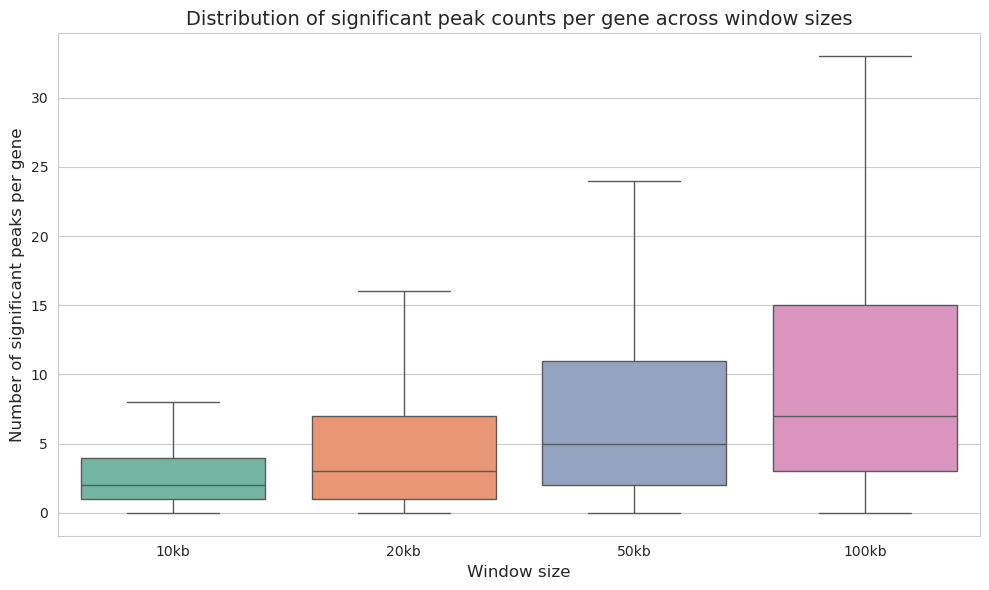

In [ ]:
#Plotting the distribution of the counts of significant peaks across all windows in a boxplot
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

# 1. Count significant peaks per gene for each window size
sig_counts = sig_cor_res_df.groupby(["window", "gene"]).size().reset_index(name="sig_peak_count")
# 2. Plot boxplot of significant peak counts per gene across window sizes
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sig_counts,
    x="window",
    y="sig_peak_count",
    palette="Set2",
    showfliers=False
)
plt.xlabel("Window size", fontsize=12)
plt.ylabel("Number of significant peaks per gene", fontsize=12)
plt.title("Distribution of significant peak counts per gene across window sizes", fontsize=14)
#plt.yscale("log")  # log scale to handle wide range of counts
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "significant_peak_counts_per_gene_boxplot_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

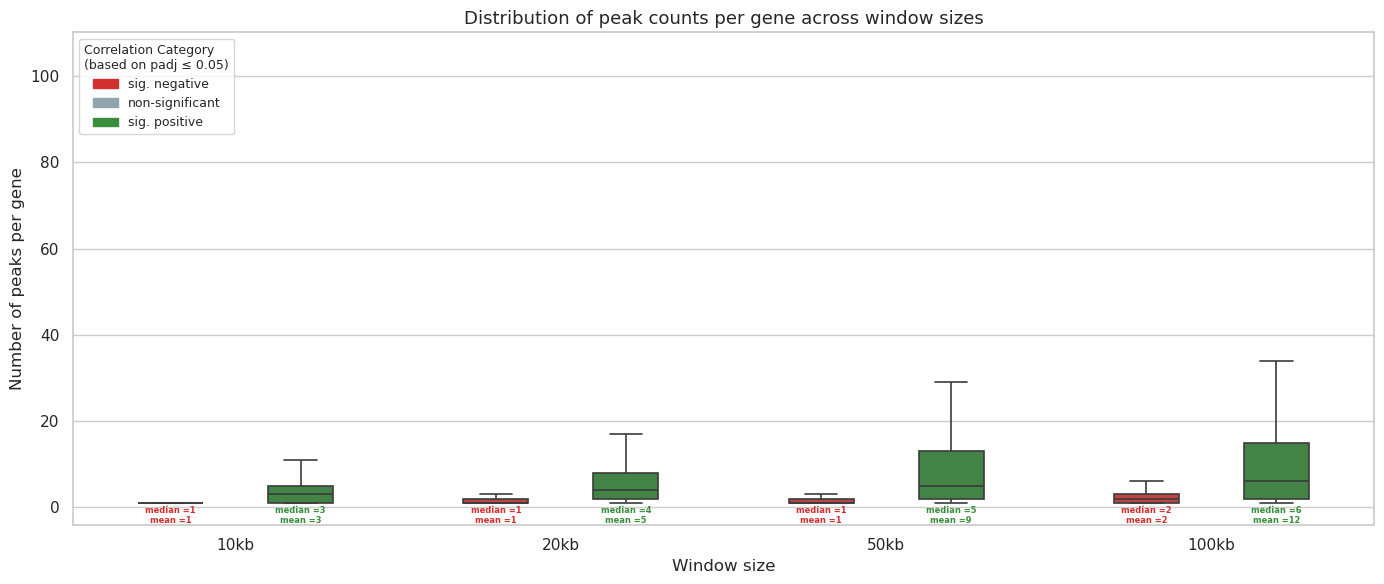

In [160]:
# Plotting the distribution of peak counts per gene across all window sizes (aggregated by category)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# ensure plot order is stable
window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative": "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive": "#388E3C",
}

# agg_df is already in long format: (window, gene, category, count)
# ensure window is categorical for proper ordering
agg_cor_df = agg_cor_df.copy()
agg_cor_df["window"] = pd.Categorical(
    agg_cor_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=agg_cor_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0,
    ),
    ax=ax,
)

# annotate median count for each window-category box
n_groups = len(category_order)
total_width = 0.6
box_width = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = agg_cor_df[agg_cor_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med = vals.median()
        y_mean = vals.mean()
        ax.text(
            x=x_pos,
             y=ax.get_ylim()[0] + 0.00001  * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            s=f"median ={int(y_med):,}\nmean ={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Correlation Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_cor_aggregated_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

Total peaks -- 50 kb: 922,652  |  100 kb: 1,853,529


Total peaks -- 50 kb: 922,652  |  100 kb: 1,853,529


/tmp/ipykernel_12855/1639168271.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


Total peaks -- 50 kb: 922,652  |  100 kb: 1,853,529


/tmp/ipykernel_12855/1639168271.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


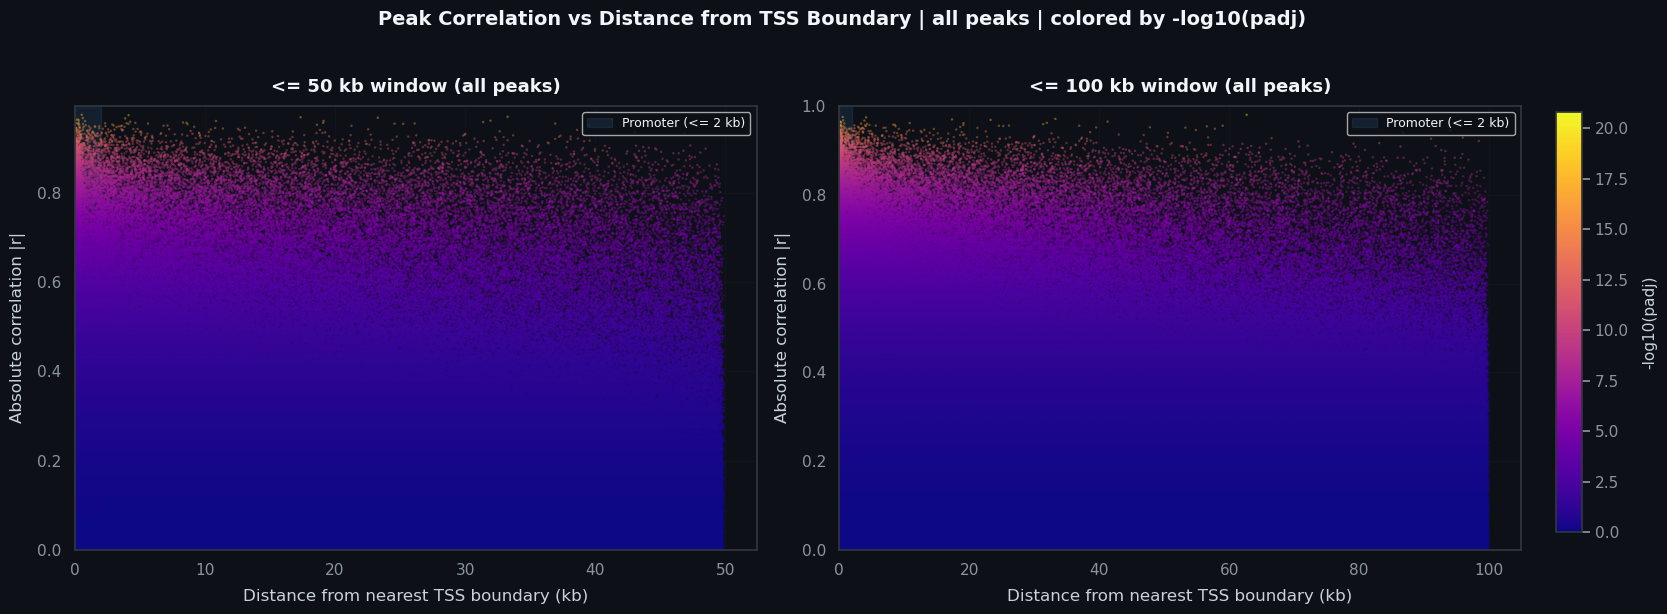

Plot saved -> peak_correlation_vs_TSS_distance_all_peaks.png


In [118]:
# Plotting peak correlation vs TSS distance (to detect potential promoter peaks)
from IPython import get_ipython
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Force notebook inline rendering even if a previous cell switched the backend
get_ipython().run_line_magic('matplotlib', 'inline')

# Load data
tss = pd.read_csv('TSS_filtered_windows.csv')
peaks = pd.read_csv('gene_peak_correlation_ct_results.csv')

# Parse peak coordinates (format: chr-start-end)
split = peaks['peak'].str.split('-', expand=True)
peaks['peak_start'] = split[1].astype(int)
peaks['peak_end'] = split[2].astype(int)
peaks['peak_mid'] = (peaks['peak_start'] + peaks['peak_end']) / 2

# Merge peaks with TSS info on gene name
merged = peaks.merge(
    tss[['gene_id', 'TSS', 'start', 'end']],
    left_on='gene',
    right_on='gene_id',
    how='left'
)

# Distance from peak midpoint to nearest TSS boundary (start or end)
merged['dist_from_TSS_boundary'] = np.minimum(
    (merged['peak_mid'] - merged['start']).abs(),
    (merged['peak_mid'] - merged['end']).abs()
)

# Use ALL peaks (no significance filter), compute neglog10_padj
merged_sig = merged.copy()
merged_sig['abs_correlation'] = merged_sig['correlation'].abs()
merged_sig['neglog10_padj'] = -np.log10(merged_sig['padj'].clip(lower=1e-300))

# Split by window
df_50 = merged_sig[merged_sig['window'] == '50kb'].copy()
df_100 = merged_sig[merged_sig['window'] == '100kb'].copy()

print(f"Total peaks -- 50 kb: {len(df_50):,}  |  100 kb: {len(df_100):,}")

def plot_panel(ax, df, title):
    if df.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Distance from nearest TSS boundary (kb)', fontsize=12, labelpad=8)
        ax.set_ylabel('Absolute correlation |r|', fontsize=12, labelpad=8)
        return None, 0.0, 0.0

    df_sorted = df.sort_values('neglog10_padj', ascending=True)
    vmin = 0.0
    vmax = float(df_sorted['neglog10_padj'].max())

    sc = ax.scatter(
        df_sorted['dist_from_TSS_boundary'] / 1000.0,
        df_sorted['abs_correlation'],
        c=df_sorted['neglog10_padj'],
        cmap='plasma',
        vmin=vmin,
        vmax=vmax,
        s=3,
        alpha=0.4,
        linewidths=0,
        rasterized=True,
    )

    ax.axvspan(0, 2, color='#58a6ff', alpha=0.10, zorder=0, label='Promoter (<= 2 kb)')
    ax.legend(loc='upper right', fontsize=9, frameon=True)

    ax.set_xlabel('Distance from nearest TSS boundary (kb)', fontsize=12, labelpad=8)
    ax.set_ylabel('Absolute correlation |r|', fontsize=12, labelpad=8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(alpha=0.25)

    ax.set_xlim(left=0)
    ax.set_ylim(0, float(df_sorted['abs_correlation'].max()) + 0.02)

    return sc, vmin, vmax

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sc50, vmin50, vmax50 = plot_panel(axes[0], df_50, '<= 50 kb window (all peaks)')
sc100, vmin100, vmax100 = plot_panel(axes[1], df_100, '<= 100 kb window (all peaks)')

vmax_global = max(vmax50, vmax100)
if sc50 is not None:
    sc50.set_clim(0, vmax_global)
if sc100 is not None:
    sc100.set_clim(0, vmax_global)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='plasma', norm=mcolors.Normalize(vmin=0, vmax=vmax_global))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(padj)', fontsize=11, labelpad=10)

fig.suptitle(
    'Peak Correlation vs Distance from TSS Boundary | all peaks | colored by -log10(padj)',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 0.91, 1])

output_file = 'peak_correlation_vs_TSS_distance_all_peaks.png'
fig.savefig(output_file, dpi=180, bbox_inches='tight')
plt.show()
print(f'Plot saved -> {output_file}')

Significant peaks (padj <= 0.05)  --  50 kb: 150,016  |  100 kb: 214,411


Significant peaks (padj <= 0.05)  --  50 kb: 150,016  |  100 kb: 214,411


/tmp/ipykernel_12855/3530671826.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


Significant peaks (padj <= 0.05)  --  50 kb: 150,016  |  100 kb: 214,411


/tmp/ipykernel_12855/3530671826.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


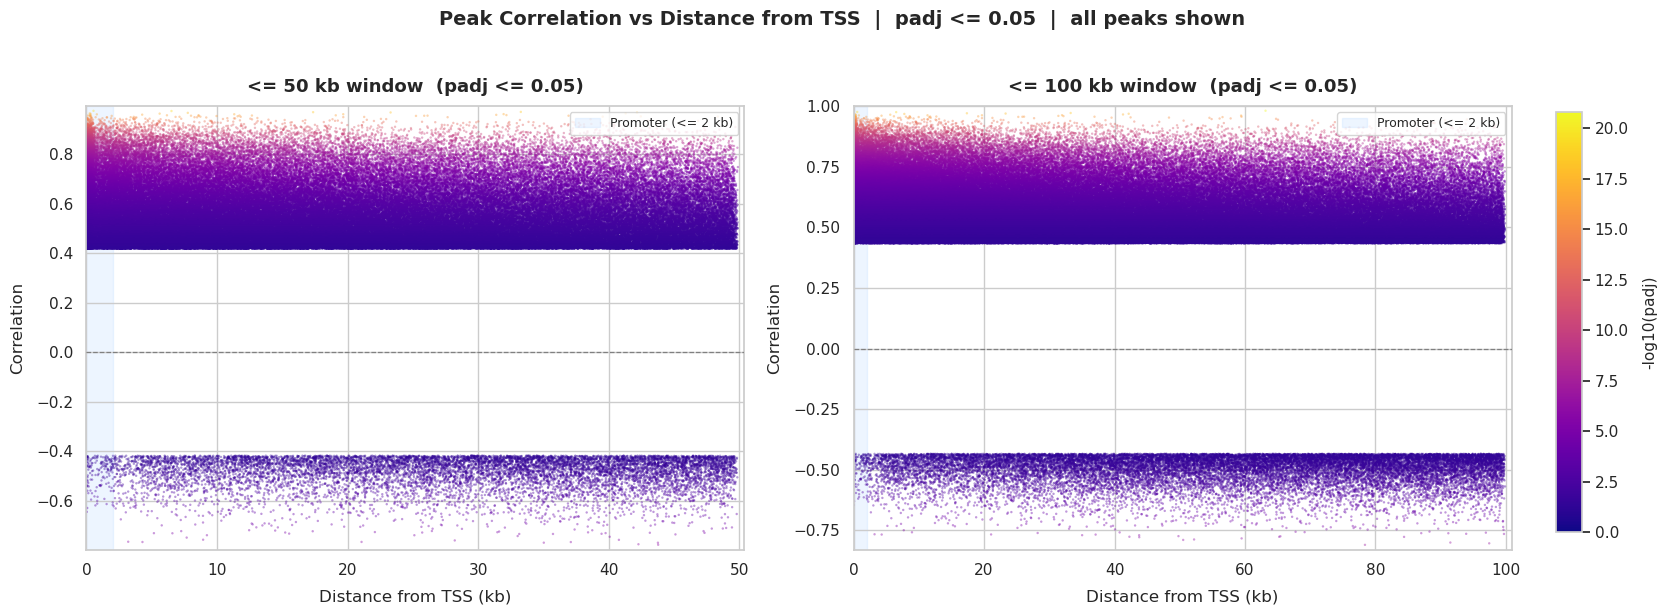

Plot saved -> peak_correlation_vs_TSS_distance_padj0.05_seaborn.png


In [120]:
from IPython import get_ipython
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

get_ipython().run_line_magic('matplotlib', 'inline')

# Load data
tss = pd.read_csv('TSS_filtered_windows.csv')
peaks = pd.read_csv('gene_peak_correlation_ct_results.csv')

# Parse peak coordinates (format: chr-start-end)
split = peaks['peak'].str.split('-', expand=True)
peaks['peak_start'] = split[1].astype(int)
peaks['peak_end'] = split[2].astype(int)
peaks['peak_mid'] = (peaks['peak_start'] + peaks['peak_end']) / 2

# Merge peaks with TSS info
merged = peaks.merge(
    tss[['gene_id', 'TSS']],
    left_on='gene', right_on='gene_id',
    how='left'
)

# Distance from peak midpoint to the TSS point
merged['dist_from_TSS_boundary'] = (merged['peak_mid'] - merged['TSS']).abs()

# Filter: padj <= 0.05, all significant peaks, no outliers dropped
merged_sig = merged[merged['padj'] <= 0.05].copy()
merged_sig['neglog10_padj'] = -np.log10(merged_sig['padj'].clip(lower=1e-300))
merged_sig['dist_kb'] = merged_sig['dist_from_TSS_boundary'] / 1000.0

# Split by window
df_50 = merged_sig[merged_sig['window'] == '50kb'].sort_values('neglog10_padj', ascending=True)
df_100 = merged_sig[merged_sig['window'] == '100kb'].sort_values('neglog10_padj', ascending=True)

print(f"Significant peaks (padj <= 0.05)  --  50 kb: {len(df_50):,}  |  100 kb: {len(df_100):,}")

# Shared color scale across both panels
vmin = 0
vmax = float(merged_sig['neglog10_padj'].max())
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

def plot_panel(ax, df, title):
    if df.empty:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(title)
        return

    colors = cmap(norm(df['neglog10_padj'].values))

    ax.scatter(
        df['dist_kb'],
        df['correlation'],
        c=colors,
        s=3,
        alpha=0.4,
        linewidths=0,
        rasterized=True
    )

    ax.axhline(0, color='gray', linewidth=0.9, linestyle='--', zorder=5)
    ax.axvspan(0, 2, color='#58a6ff', alpha=0.10, zorder=0, label='Promoter (<= 2 kb)')
    ax.legend(loc='upper right', fontsize=9, frameon=True)

    ax.set_xlabel('Distance from TSS (kb)', fontsize=12, labelpad=8)
    ax.set_ylabel('Correlation', fontsize=12, labelpad=8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    ax.set_xlim(left=0, right=df['dist_kb'].max() * 1.01)
    ax.set_ylim(
        df['correlation'].min() - 0.02,
        df['correlation'].max() + 0.02
    )

plot_panel(axes[0], df_50, '<= 50 kb window  (padj <= 0.05)')
plot_panel(axes[1], df_100, '<= 100 kb window  (padj <= 0.05)')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('-log10(padj)', fontsize=11, labelpad=10)

fig.suptitle(
    'Peak Correlation vs Distance from TSS  |  padj <= 0.05  |  all peaks shown',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout(rect=[0, 0, 0.91, 1])

output_file = 'peak_correlation_vs_TSS_distance_padj0.05_seaborn.png'
fig.savefig(output_file, dpi=180, bbox_inches='tight')
plt.show()
print(f'Plot saved -> {output_file}')

In [60]:
# Subset the cor_results of all window size dictionaries to only include gene-peak pairs with a significant correlation (p-value <= 0.05)
sig_cor_res_df = cor_res_df[cor_res_df["padj"] <= 0.05].copy()

sig_agg_cor_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
sig_agg_cor_df.tail()
cor_res_df["gene"]

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category
0,10kb,rpl24,1-2372-3057,0.094215,0.568340,0.245392,0.724824,0.139767,non-significant
1,10kb,rpl24,1-3427-4032,-0.143691,0.382828,0.416996,0.565719,0.247399,non-significant
2,10kb,rpl24,1-4469-7268,-0.038134,0.817717,0.087397,0.897746,0.046846,non-significant
3,10kb,rpl24,1-9541-9969,-0.087968,0.594363,0.225948,0.744353,0.128221,non-significant
4,10kb,rpl24,1-11007-12962,0.025887,0.875692,0.057649,0.932150,0.030514,non-significant


In [63]:
cor_res_df.pvalue.max()

np.float64(0.9999990478317607)

/tmp/ipykernel_12855/2176621444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


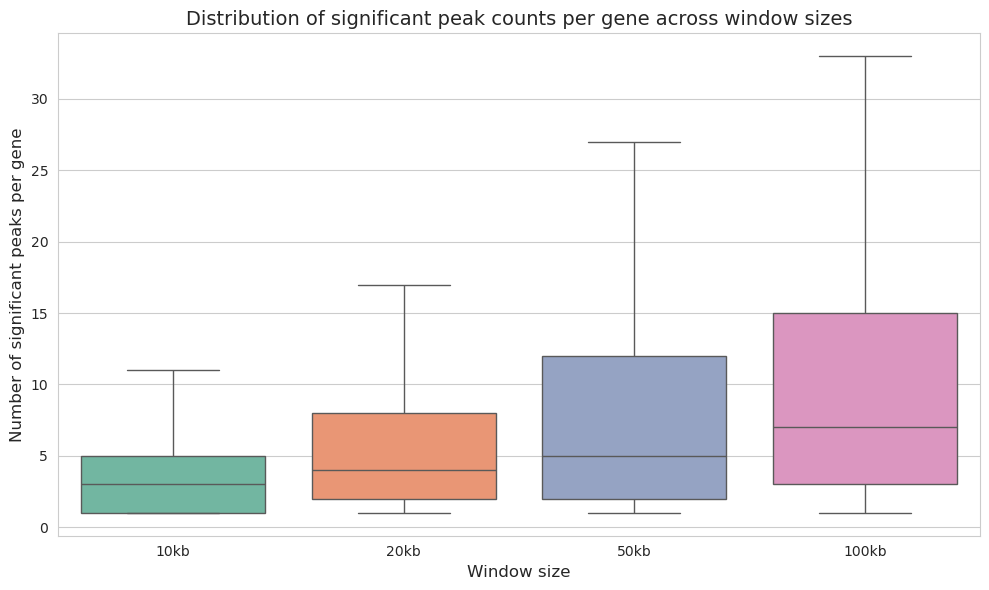

In [66]:
#Plotting the distribution of the counts of significant peaks across all windows in a boxplot
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   


# 1. Count significant peaks per gene for each window size
sig_counts = sig_cor_res_df.groupby(["window", "gene"]).size().reset_index(name="sig_peak_count")
# 2. Plot boxplot of significant peak counts per gene across window sizes
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sig_counts,
    x="window",
    y="sig_peak_count",
    order=["10kb", "20kb", "50kb", "100kb"],
    palette="Set2",
    showfliers=False
)
plt.xlabel("Window size", fontsize=12)
plt.ylabel("Number of significant peaks per gene", fontsize=12)
plt.title("Distribution of significant peak counts per gene across window sizes", fontsize=14)
#plt.yscale("log")  # log scale to handle wide range of counts
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "significant_peak_counts_per_gene_boxplot_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()